### CAMB tutorial

In [31]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import numpy as np
import matplotlib.pyplot as plt
import camb.model, camb.initialpower

In [32]:
# set parameters for camb
params = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
# h0
# omega_b*h^2 - baryon density
# omega_b*c^2 - dark density
# mnu - sum neutrino masses
# omega_k
# tau - reionization depth, photon scattering depth
# As - primordial perturbation amplitude
# ns - scalar spectral index, tilt
# halofit vers - 'mead', nonlinear correction model
# lmax=3000 - max multipole moment, resolution 

#### matter power spectrum (part of tutorial)

In [33]:
# now get matter power spectra and sigma8 at redshift 0 and 0.8
import camb.model as model


params=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)
# note: non-linear corrections couples to smaller scales than you want
params.set_matter_power(redshifts=[0.0, 1], kmax=2.0) # P(k) at specific z, upto k=2h/Mpc

# linear spectra
params.NonLinear = model.NonLinear_none # is nonlinear structure included or not - here linear
results=camb.get_results(params) # compute transfer and power spectra
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints=200) 
# returns:
    # kh - contains wavenumbers  k/h between 1e-4-1
    # z - specific zs
    # pk - power spectrum at each redshift with pk[0, :] corresponding to one
s8= np.array(results.get_sigma8) # compute sigma8

# non-linear spectra (halofit)
params.NonLinear = model.NonLinear_both 
results.calc_power_spectra(params) 
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints=200)

print('sigma_8 values at the two redshifts: ', results.get_sigma8())

Note: redshifts have been re-sorted (earliest first)
sigma_8 values at the two redshifts:  [0.48696308 0.802608  ]


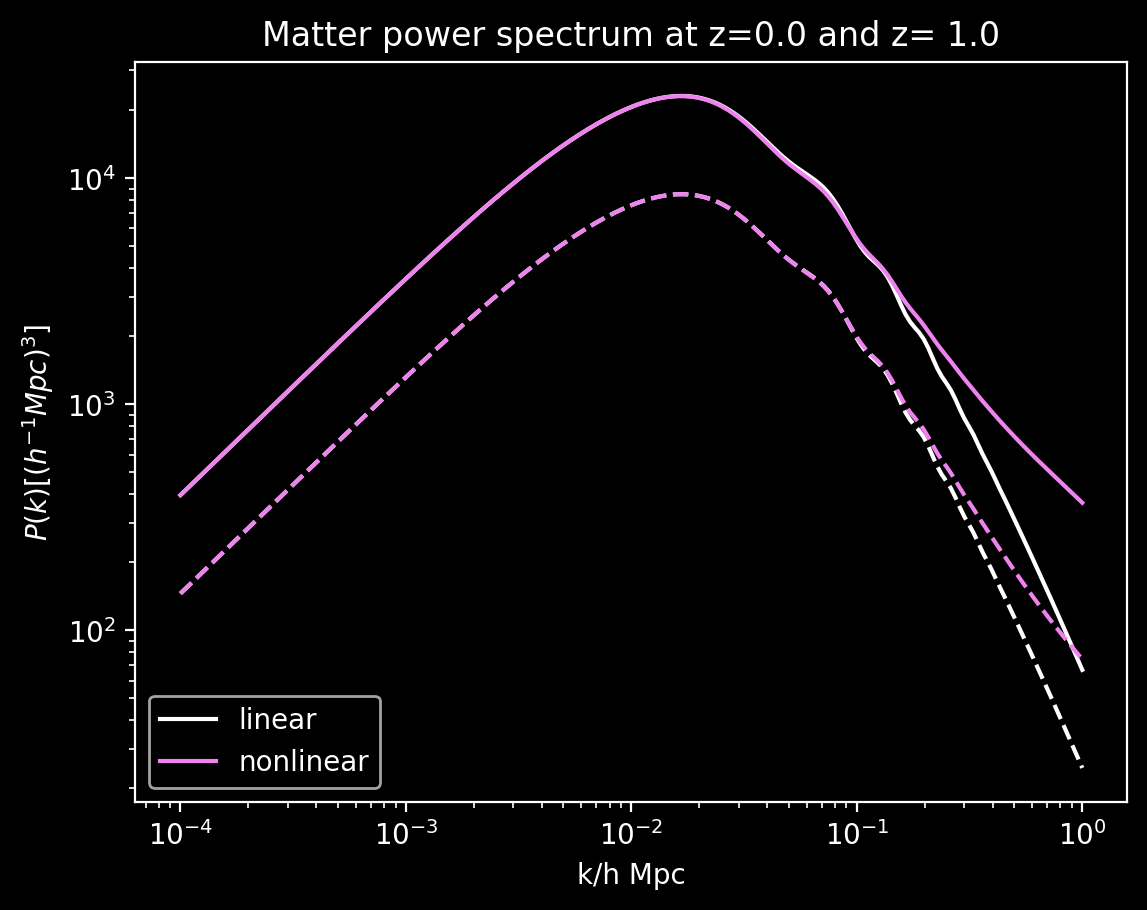

In [34]:
plt.style.use('dark_background')


for i, (redshift, line) in enumerate(zip(z, ['-', '--'])): 
    # - for z[0] and -- for z[1] - a tuple
    # with index added
    plt.loglog(kh, pk[i, :], color='w', ls=line)
    plt.loglog(kh_nonlin, pk_nonlin[i, :], color='violet', ls=line)
plt.xlabel('k/h Mpc')
plt.ylabel(r'$P(k) [(h^{-1}Mpc)^3]$')
plt.legend(['linear', 'nonlinear'], loc='lower left')
plt.title('Matter power spectrum at z=%s and z= %s' % tuple(z)); # cast z tuple
plt.show()

### limber integral

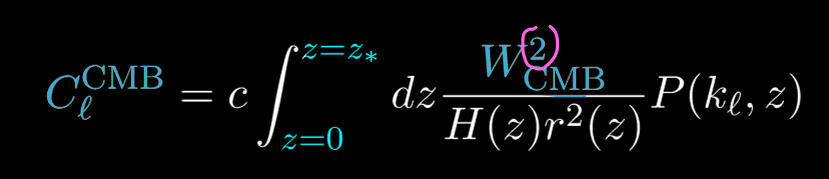
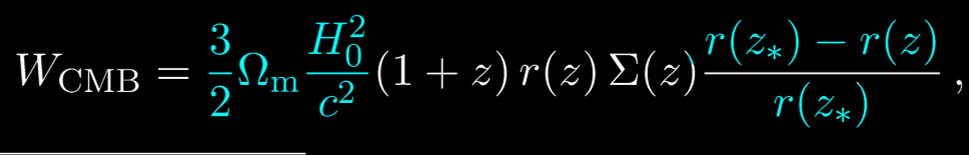

In [39]:
import astropy.constants as constants
from astropy.cosmology import FlatLambdaCDM
from scipy.integrate import quad 


# astropy cosmology set based on CAMB

# NOTE: this is to keep units in k[hMpc-1]
h = params.H0/100
c = constants.c.to('km/s').value
z_star = results.get_derived_params()['zstar'] # 1100 but can be something else like 10-20


cosmology = FlatLambdaCDM(H0=params.H0, Om0=params.omegam)
power_spec_calculator = camb.get_matter_power_interpolator(
    params,
    nonlinear=True,
    k_hunit=True, # can remove this and 'h' also
    kmax=10.0,
    zmax=z_star
) 

# get recombination z
comoving_zstar = cosmology.comoving_distance(z_star).value


def limber_integral(ell, mu, eta):

    def integrand(z):
        comoving_dist = cosmology.comoving_distance(z).value
        k = (ell+0.5)/comoving_dist*h
        W_CMB = cmb_radial_kernel(z, mu, eta)
        Hz = cosmology.H(z).value
        P_mm = power_spec_calculator.P(z, k) 
        return (W_CMB**2*Hz)/(comoving_dist**2)*P_mm

    return (1/c)*quad(integrand, 0, z_star)[0]


def cmb_radial_kernel(z, mu, eta): # from sankar
    comoving_z = cosmology.comoving_distance(z).value
    constant_term = (3/2)*(params.omegam)*((params.H0)/(c))**2
    comoving_terms = (1+z)*comoving_z*(comoving_zstar-comoving_z)/(comoving_zstar)
    return (constant_term*comoving_terms*sigma(mu, eta))

def cmb_radial_kernel2(z, mu, eta): # from karim modified to add MG
    constant_term = (3/2)*(params.omegam)/c*(params.H0)**2/cosmology.H(z).value
    comoving_term = (1+z)*cosmology.comoving_distance(z).value*(1-cosmology.comoving_distance(z).value/comoving_zstar)
    return constant_term*comoving_term*sigma(mu, eta)


def sigma(mu, eta):
    return 0.5*mu*(1+eta)




### plotting kernel to see how it changes with different MG params

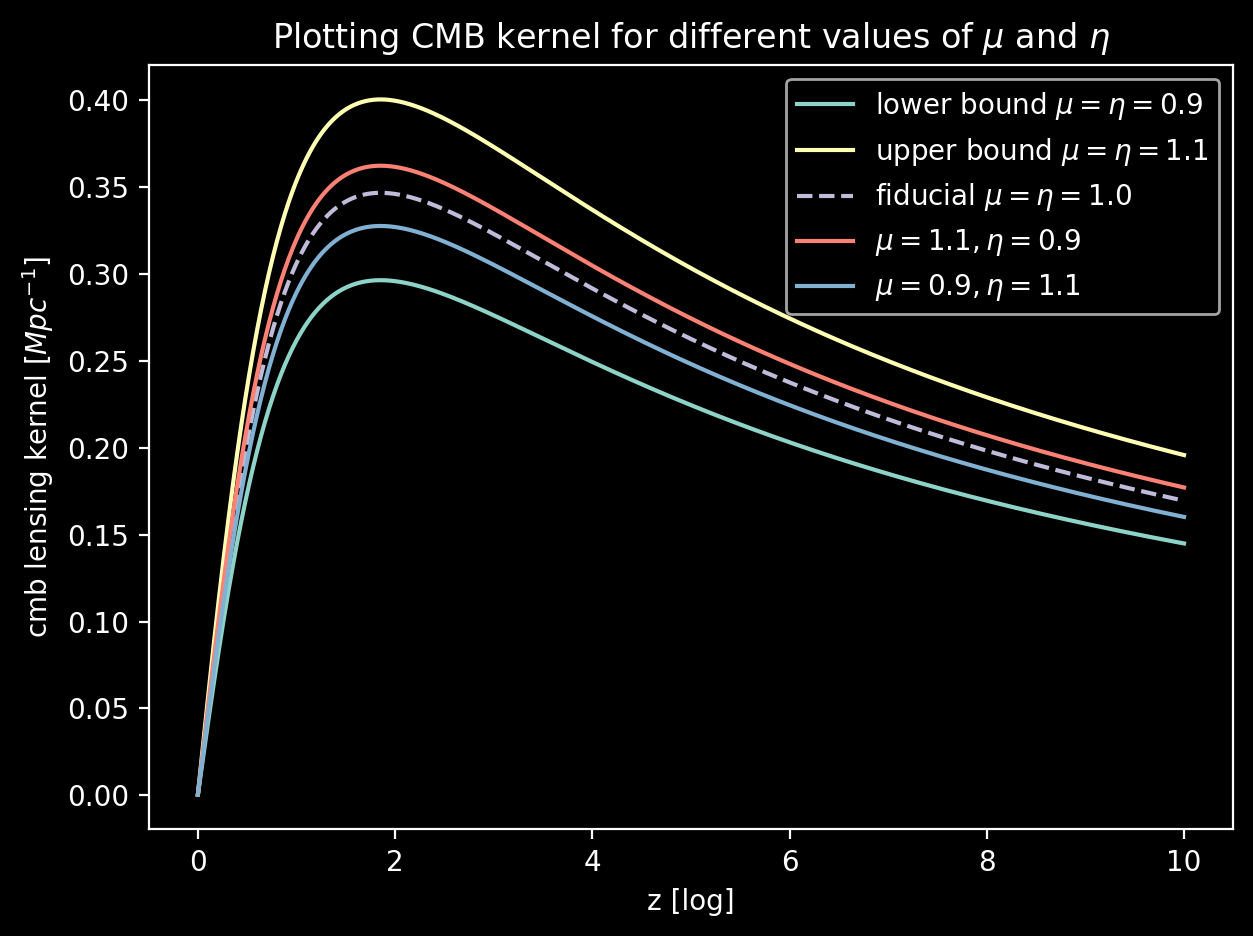

In [40]:
# bounds of prior and fiducial params

mu_lower, eta_lower = 0.9, 0.9
mu_higher, eta_higher = 1.1, 1.1
mu_fiducial, eta_fiducial = 1.0, 1.0

z_range = np.linspace(0.001, 10, 1000)
kernel1 = np.array(cmb_radial_kernel2(z_range, mu_lower, eta_lower))
kernel2 = np.array([cmb_radial_kernel2(z, mu_higher, eta_higher) for z in z_range])
kernel3 = np.array([cmb_radial_kernel2(z, mu_fiducial, eta_fiducial) for z in z_range])
kernel4 = np.array([cmb_radial_kernel2(z, mu_higher, eta_lower) for z in z_range])
kernel5 = np.array([cmb_radial_kernel2(z, mu_lower, eta_higher) for z in z_range])


plt.plot(z_range, kernel1)
plt.plot(z_range, kernel2)
plt.plot(z_range, kernel3, linestyle='--')
plt.plot(z_range, kernel4)
plt.plot(z_range, kernel5)
plt.xlabel('z [log]')
plt.ylabel(r'cmb lensing kernel $[Mpc^{-1}]$')
plt.legend([r'lower bound $\mu=\eta=0.9$', r'upper bound $\mu=\eta=1.1$', r'fiducial $\mu=\eta=1.0$',  r'$\mu=1.1, \eta=0.9$', r'$\mu=0.9, \eta=1.1$'])
plt.title(r'Plotting CMB kernel for different values of $\mu$ and $\eta$')
plt.tight_layout()
plt.show()


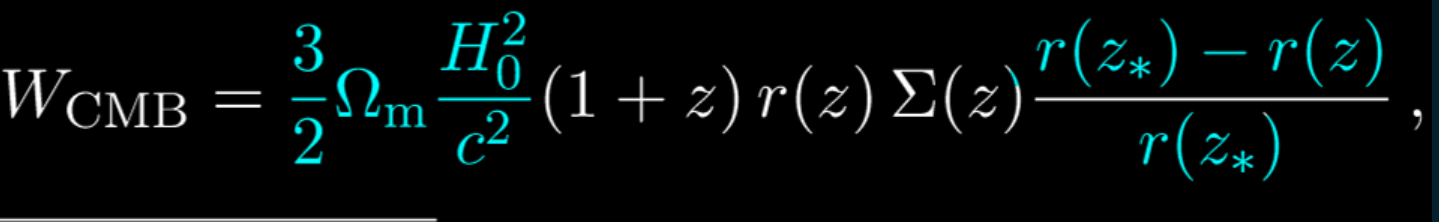

### apply limber integral to camb matter power spectrum 


Text(0.5, 1.0, '$C_\\ell^{\\kappa \\kappa}$')

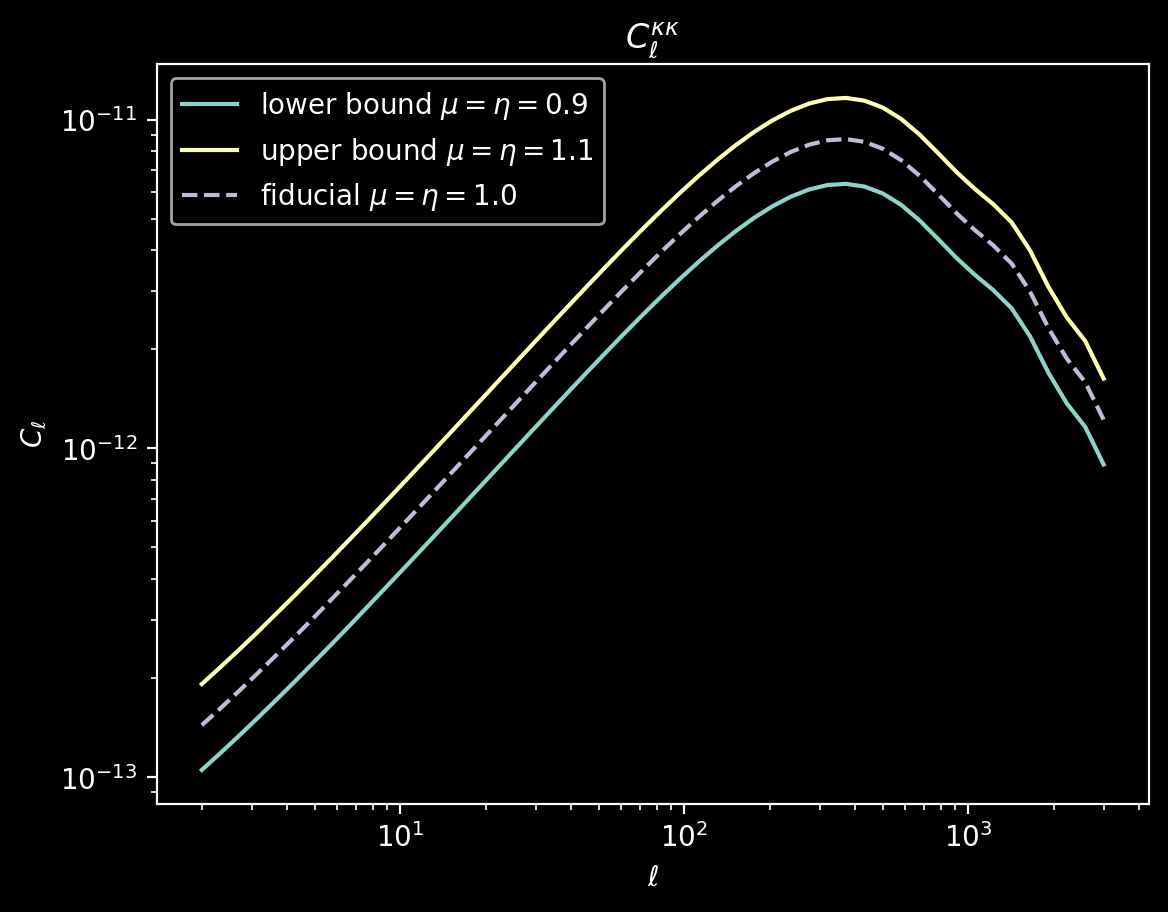

In [41]:
# Cl plot as a function of ell

ells = np.logspace(np.log10(2), np.log10(3000), 50)
Cls = [limber_integral(ell, 0.9, 0.9) for ell in ells] 
Cls1 = [limber_integral(ell, 1.1, 1.1) for ell in ells] 
Cls2 = [limber_integral(ell, 1.0, 1.0) for ell in ells] # default MG values

pars = camb.set_params(
    H0=67.5,
    ombh2=0.022,
    omch2=0.122,
    ns=0.965
)

plt.loglog(ells, Cls)
plt.loglog(ells, Cls1)
plt.loglog(ells, Cls2, linestyle='--')


plt.legend([r'lower bound $\mu=\eta=0.9$', r'upper bound $\mu=\eta=1.1$', r'fiducial $\mu=\eta=1.0$',  r'CAMB'])

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.title(r'$C_\ell^{\kappa \kappa}$')

